# Stable Diffusion 1.5: sample grids on gender

For *A face of a doctor* and *A face of a firefighter*, six images unguided (top row) and six under
Debias Anything at a gender target of one half (bottom row): $w_{fair} = 3000$, guidance for
$\sigma \in [0.2, 4]$, *a photo of a man* / *a photo of a woman*, with the released adapter. Euler
sampler with trailing timesteps, 30 steps, classifier-free guidance 7.5, the negative prompt below.
The six images of a row share one CUDA generator, seeded with `SEED`, so column $i$ of both rows
starts from the same noise.

Guided sampling on Stable Diffusion is not bit-reproducible: the backward pass through the attention
layers is nondeterministic on GPU, and two runs differ by about 0.5 grey level per pixel on average.
Figures are written to `outputs/figures/sd15/`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from debias_anything.guidance.sd15 import DebiasAnythingSD15
from debias_anything.models.sd15 import load_pipeline

ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)

OUT = ROOT / "outputs/figures/sd15"
OUT.mkdir(parents=True, exist_ok=True)
SEED = 3
PROMPTS = [
    ("A face of a doctor", SEED),
    ("A face of a firefighter", SEED),
]  # (prompt, seed)
N = 6
W = 3000.0
SIGMA_MIN, SIGMA_MAX = 0.2, 4.0
STEPS, GUIDANCE_SCALE = 30, 7.5
SOURCE, TARGETS = "a photo of a man", ["a photo of a woman"]
NEGATIVE_PROMPT = (
    "blurry, low quality, low resolution, artifacts, watermark, text, signature, deformed, "
    "disfigured, bad anatomy, extra limbs, cropped, out of frame, cartoon"
)

pipe = load_pipeline("cuda", DebiasAnythingSD15, scheduler="euler")
pipe.set_progress_bar_config(disable=True)
pipe.setup(
    "google/siglip2-base-patch16-224",
    str(ROOT / "checkpoints/sd15_adapter.pth"),
    SOURCE,
    TARGETS,
)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 3894.82it/s]


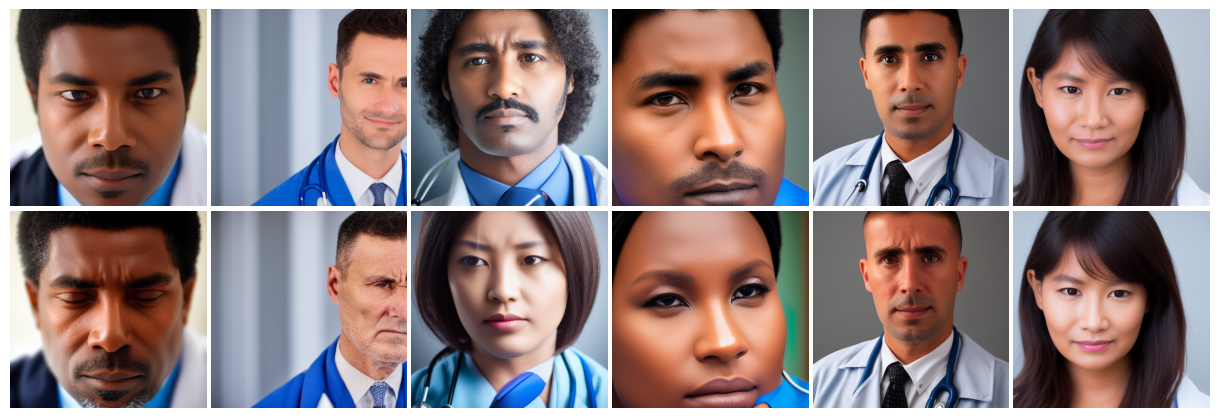

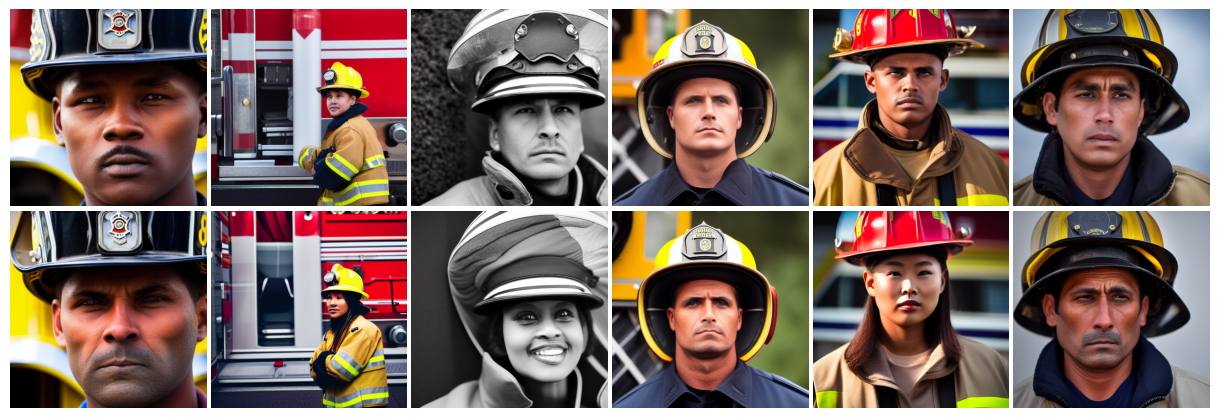

In [6]:
for prompt, seed in PROMPTS:
    rows = [
        pipe(
            [prompt],
            num_inference_steps=STEPS,
            guidance_scale=GUIDANCE_SCALE,
            negative_prompt=NEGATIVE_PROMPT,
            num_images_per_prompt=N,
            generator=torch.Generator(device="cuda").manual_seed(seed),
            weight=weight,
            sigma_min=SIGMA_MIN,
            sigma_max=SIGMA_MAX,
        )
        for weight in (0.0, W)  # unguided, Debias Anything
    ]
    fig, axes = plt.subplots(2, N, figsize=(2 * N, 4), squeeze=False)
    for axes_row, images in zip(axes, rows):
        for ax, image in zip(axes_row, images):
            ax.imshow(image)
            ax.axis("off")
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.02, hspace=0.02)
    fig.savefig(
        OUT / f"{prompt.replace(' ', '_')}_seed{seed}.pdf",
        bbox_inches="tight",
        pad_inches=0.01,
    )
    plt.show()